In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

In [2]:
# load the dataset
read =pd.read_csv(r"C:\Users\chris\OneDrive\Documents\Desktop\heart_disease\heart_disease_uci.csv")
df = pd.DataFrame(read)
df.head()

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


In [3]:
df.info() #columnn names

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        920 non-null    int64  
 1   age       920 non-null    int64  
 2   sex       920 non-null    object 
 3   dataset   920 non-null    object 
 4   cp        920 non-null    object 
 5   trestbps  861 non-null    float64
 6   chol      890 non-null    float64
 7   fbs       830 non-null    object 
 8   restecg   918 non-null    object 
 9   thalch    865 non-null    float64
 10  exang     865 non-null    object 
 11  oldpeak   858 non-null    float64
 12  slope     611 non-null    object 
 13  ca        309 non-null    float64
 14  thal      434 non-null    object 
 15  num       920 non-null    int64  
dtypes: float64(5), int64(3), object(8)
memory usage: 115.1+ KB


In [4]:
# Statistical summary
df.describe(include='all')

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
count,920.000000,920.000000,920,920,920,861.000000,890.000000,830,918,865.000000,865,858.000000,611,309.000000,434,920.000000
unique,NaN,NaN,2,4,4,NaN,NaN,2,3,NaN,2,NaN,3,NaN,3,NaN
top,NaN,NaN,Male,Cleveland,asymptomatic,NaN,NaN,False,normal,NaN,False,NaN,flat,NaN,normal,NaN
freq,NaN,NaN,726,304,496,NaN,NaN,692,551,NaN,528,NaN,345,NaN,196,NaN
mean,460.500000,53.510870,NaN,NaN,NaN,132.132404,199.130337,NaN,NaN,137.545665,NaN,0.878788,NaN,0.676375,NaN,0.995652
std,265.725422,9.424685,NaN,NaN,NaN,19.066070,110.780810,NaN,NaN,25.926276,NaN,1.091226,NaN,0.935653,NaN,1.142693
min,1.000000,28.000000,NaN,NaN,NaN,0.000000,0.000000,NaN,NaN,60.000000,NaN,-2.600000,NaN,0.000000,NaN,0.000000
25%,230.750000,47.000000,NaN,NaN,NaN,120.000000,175.000000,NaN,NaN,120.000000,NaN,0.000000,NaN,0.000000,NaN,0.000000
50%,460.500000,54.000000,NaN,NaN,NaN,130.000000,223.000000,NaN,NaN,140.000000,NaN,0.500000,NaN,0.000000,NaN,1.000000
75%,690.250000,60.000000,NaN,NaN,NaN,140.000000,268.000000,NaN,NaN,157.000000,NaN,1.500000,NaN,1.000000,NaN,2.000000


In [5]:
df.isna().sum() #  checking the null values in each columns

id            0
age           0
sex           0
dataset       0
cp            0
trestbps     59
chol         30
fbs          90
restecg       2
thalch       55
exang        55
oldpeak      62
slope       309
ca          611
thal        486
num           0
dtype: int64

In [6]:
# Automatically detect target column
possible_targets = ['condition', 'target', 'num', 'diagnosis']

target_col = None
for col in possible_targets:
    if col in df.columns:
        target_col = col
        break

print("Detected target column:", target_col)


Detected target column: num


In [7]:
# If your target column is string-based (like "presence"/"absence"), convert to 0/1
if df[target_col].dtype == 'object':
    df[target_col] = df[target_col].map({'healthy': 0, 'presence': 1, 'absence': 0, 
                                         'disease': 1, 'no disease': 0}).fillna(1).astype(int)

df[target_col].value_counts()


num
0    411
1    265
2    109
3    107
4     28
Name: count, dtype: int64

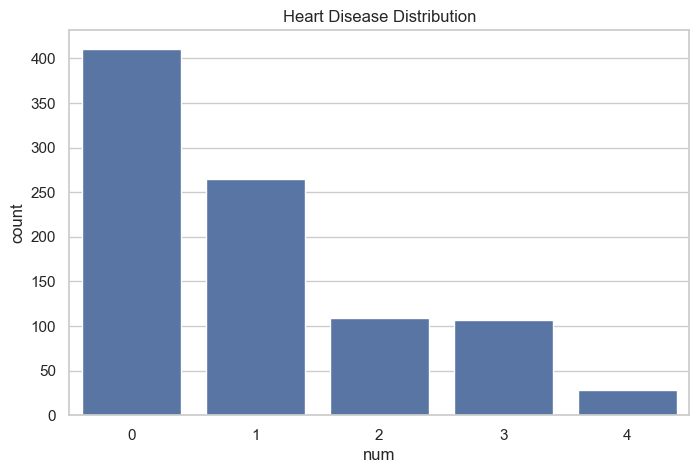

In [8]:
# Target distribution
sns.countplot(data=df, x=target_col)
plt.title("Heart Disease Distribution")
plt.show()

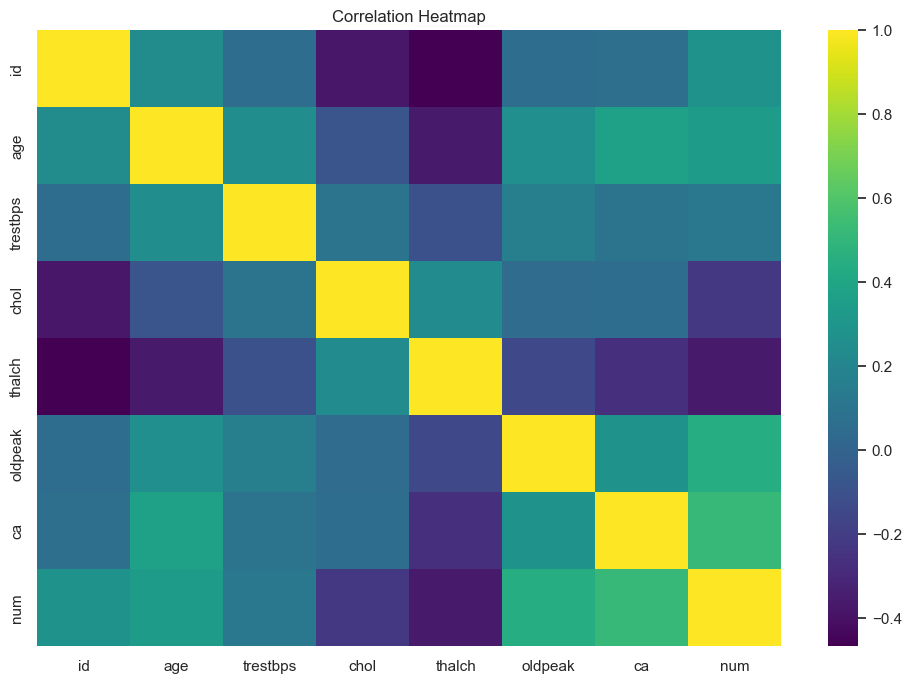

In [9]:
# Correlation heatmap (only numeric columns)
plt.figure(figsize=(12, 8))
sns.heatmap(df.select_dtypes(include=['number']).corr(), annot=False, cmap='viridis')
plt.title("Correlation Heatmap")
plt.show()

In [10]:
# Drop ID/dataset columns if present (they are not useful for ML)
drop_cols = ['id', 'dataset']
for col in drop_cols:
    if col in df.columns:
        df = df.drop(columns=[col])

df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,63,Male,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,67,Male,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,67,Male,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,37,Male,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,41,Female,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


In [11]:
# check missing values
missing = df.isna().sum().sort_values(ascending=False)
print(missing)

ca          611
thal        486
slope       309
fbs          90
oldpeak      62
trestbps     59
thalch       55
exang        55
chol         30
restecg       2
cp            0
sex           0
age           0
num           0
dtype: int64


In [12]:
target_col = "thal"

In [13]:
known_data = df[df[target_col].notna()].copy()
unknown_data = df[df[target_col].isna()].copy()

print("Known:", known_data.shape)
print("Missing:", unknown_data.shape)

Known: (434, 14)
Missing: (486, 14)


In [14]:
predictor_cols = [
    col for col in df.columns 
    if col not in ["thal", "ca"]
]

In [15]:
# fill numeric columns
for col in predictor_cols:
    if df[col].dtype != 'object':
        median_val = known_data[col].median()
        known_data[col] = known_data[col].fillna(median_val)
        unknown_data[col] = unknown_data[col].fillna(median_val)

# fill categorical columns
for col in predictor_cols:
    if df[col].dtype == 'object':
        mode_val = known_data[col].mode()[0]
        known_data[col] = known_data[col].fillna(mode_val)
        unknown_data[col] = unknown_data[col].fillna(mode_val)

C:\Users\chris\AppData\Local\Temp\ipykernel_17088\1955153553.py:12: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  known_data[col] = known_data[col].fillna(mode_val)
C:\Users\chris\AppData\Local\Temp\ipykernel_17088\1955153553.py:13: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  unknown_data[col] = unknown_data[col].fillna(mode_val)


In [16]:
from sklearn.preprocessing import LabelEncoder

encoders = {}

for col in predictor_cols + [target_col]:
    if known_data[col].dtype == 'object':
        le = LabelEncoder()
        
        known_data[col] = le.fit_transform(known_data[col])
        
        if col in unknown_data:
            unknown_data[col] = unknown_data[col].map(
                lambda x: le.transform([x])[0] if x in le.classes_ else -1
            )
        
        encoders[col] = le

In [17]:
from sklearn.ensemble import RandomForestClassifier

X_train = known_data[predictor_cols]
y_train = known_data[target_col]

model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)

RandomForestClassifier(n_estimators=200, n_jobs=-1, random_state=42)

In [18]:
X_pred = unknown_data[predictor_cols]

predictions = model.predict(X_pred)
[ len(predictions) == len(unknown_data)] # check the size of the predicted number

[True]

In [19]:
# 1. Redefine the mask based on where the target column is missing 
# OR use the index of the data you predicted on
# If you have a dataframe called 'unknown_data' that you used for predictions:
mask = df.index.isin(unknown_data.index)

# 2. Check the counts again
print(f"Rows identified by mask: {mask.sum()}")
print(f"Predictions count: {len(predictions)}")

# 3. If they match, apply the inverse transform and fill in one go
if mask.sum() == len(predictions):
    le_target = encoders[target_col]
    
    # Convert predictions to int, then to original labels, then fill df
    decoded_preds = le_target.inverse_transform(predictions.astype(int))
    df.loc[mask, target_col] = decoded_preds
    print("Success! Values filled and decoded.")
else:
    print("Error: The number of rows in the mask still doesn't match predictions.")

Rows identified by mask: 486
Predictions count: 486
Success! Values filled and decoded.


In [20]:
df.isna().sum()

age           0
sex           0
cp            0
trestbps     59
chol         30
fbs          90
restecg       2
thalch       55
exang        55
oldpeak      62
slope       309
ca          611
thal          0
num           0
dtype: int64

In [21]:
# Fill all numerical columns with their respective medians
df = df.fillna(df.select_dtypes(include='number').median())

# Fill all categorical columns with their respective modes
# Note: mode() returns a DataFrame, so we take the first row with .iloc
for col in df.select_dtypes(include='object').columns:
    df[col] = df[col].fillna(df[col].mode())

In [22]:
df.isna().sum()

age           0
sex           0
cp            0
trestbps      0
chol          0
fbs          90
restecg       2
thalch        0
exang        55
oldpeak       0
slope       309
ca            0
thal          0
num           0
dtype: int64

In [23]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

X = known_data[predictor_cols]
y = known_data[target_col]

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model.fit(X_train, y_train)

preds = model.predict(X_val)

print("Validation Accuracy:", accuracy_score(y_val, preds))

Validation Accuracy: 0.7126436781609196


In [24]:
target_col = "slope"
known_data = df[df[target_col].notna()].copy()
unknown_data = df[df[target_col].isna()].copy()

print("Known:", known_data.shape)
print("Missing:", unknown_data.shape)

Known: (611, 14)
Missing: (309, 14)


In [25]:
predictor_cols = [
    col for col in df.columns 
    if col not in ["slope", "ca"]
]

In [26]:
for col in predictor_cols:
    if df[col].dtype != 'object':
        median_val = known_data[col].median()
        known_data[col] = known_data[col].fillna(median_val)
        unknown_data[col] = unknown_data[col].fillna(median_val)

for col in predictor_cols:
    if df[col].dtype == 'object':
        mode_val = known_data[col].mode()[0]
        known_data[col] = known_data[col].fillna(mode_val)
        unknown_data[col] = unknown_data[col].fillna(mode_val)

C:\Users\chris\AppData\Local\Temp\ipykernel_17088\603924591.py:10: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  known_data[col] = known_data[col].fillna(mode_val)
C:\Users\chris\AppData\Local\Temp\ipykernel_17088\603924591.py:11: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  unknown_data[col] = unknown_data[col].fillna(mode_val)


In [27]:
from sklearn.preprocessing import LabelEncoder

if "slope" not in encoders:
    encoders["slope"] = LabelEncoder()

# Encode target
known_data["slope"] = encoders["slope"].fit_transform(known_data["slope"])

# Encode predictors (only if needed)
for col in predictor_cols:
    if known_data[col].dtype == 'object':
        if col not in encoders:
            encoders[col] = LabelEncoder()
            known_data[col] = encoders[col].fit_transform(known_data[col])
        else:
            known_data[col] = encoders[col].transform(known_data[col])

        unknown_data[col] = unknown_data[col].map(
            lambda x: encoders[col].transform([x])[0] if x in encoders[col].classes_ else -1
        )

In [28]:
from sklearn.ensemble import RandomForestClassifier

X_train = known_data[predictor_cols]
y_train = known_data[target_col]

model = RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    min_samples_split=5,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)

RandomForestClassifier(max_depth=10, min_samples_split=5, n_estimators=300,
                       n_jobs=-1, random_state=42)

In [29]:
X_pred = unknown_data[predictor_cols]

predictions = model.predict(X_pred)
predictions

array([2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 1, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 1, 1, 2, 2, 2, 2, 2, 2, 1, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 1, 1, 1, 2,
       2, 2, 2, 1, 1, 2, 2, 1, 2, 2, 2, 2, 2, 2, 2, 1, 2, 2, 2, 2, 2, 2,
       1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 1, 2, 1, 2, 2, 2, 2, 1, 2, 2,
       2, 2, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 1, 2, 2, 2, 2, 2, 2, 1, 2, 1, 2,
       2, 1, 2, 2, 2, 2, 2, 2, 1, 1, 1, 2, 2, 1, 2, 1, 1, 1, 1, 2, 2, 1,
       1, 1, 1, 1, 1, 1, 2, 2, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 1, 2, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1,
       1, 2, 2, 1, 1, 1, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 2, 1, 1, 2, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 1, 1,
       1, 2, 2, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 2, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 1,

In [30]:
le_target = encoders[target_col]
decoded_labels = le_target.inverse_transform(predictions.astype(int))
df.loc[unknown_data.index, target_col] = decoded_labels

In [31]:
df.isna().sum()

age          0
sex          0
cp           0
trestbps     0
chol         0
fbs         90
restecg      2
thalch       0
exang       55
oldpeak      0
slope        0
ca           0
thal         0
num          0
dtype: int64

In [32]:
print(df["ca"].value_counts())

ca
0.0    792
1.0     67
2.0     41
3.0     20
Name: count, dtype: int64


In [33]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

X = known_data[predictor_cols]
y = known_data[target_col]

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model.fit(X_train, y_train)

preds = model.predict(X_val)

print("Validation Accuracy:", accuracy_score(y_val, preds))

Validation Accuracy: 0.6747967479674797


In [34]:
df.rename(columns={'thalch': 'thalach','trestbps': 'resting_bps','chol': 'serum_chol','fbs': 'fasting_bs','restegc': 'rest_ecg'}, inplace=True)
df.head()

,age,sex,cp,resting_bps,serum_chol,fasting_bs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
0,63,Male,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,67,Male,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,67,Male,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,37,Male,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,41,Female,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


In [35]:
# Convert columns to proper types where possible
numeric_cols = ["age", "resting_bps", "serum_chol", "thalach", "oldpeak", "ca", "num"]
for col in numeric_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

In [36]:
# Fill missing values

# Numerical columns: fill with median
num_fill_cols = ["resting_bps", "serum_chol", "thalach", "oldpeak", "ca"]
for col in num_fill_cols:
    if df[col].isna().sum()>0:
        df[col] = df[col].fillna(df[col].median())

# Categorical columns: fill with mode
cat_fill_cols = ["sex", "dataset", "cp", "fasting_bs", "restecg", "exang"]
for col in cat_fill_cols:
    if col in df.columns:
        df[col] = df[col].fillna(df[col].mode()[0])

C:\Users\chris\AppData\Local\Temp\ipykernel_17088\3649786291.py:13: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[col] = df[col].fillna(df[col].mode()[0])


In [37]:
df.isna().sum()

age            0
sex            0
cp             0
resting_bps    0
serum_chol     0
fasting_bs     0
restecg        0
thalach        0
exang          0
oldpeak        0
slope          0
ca             0
thal           0
num            0
dtype: int64

In [38]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 14 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   age          920 non-null    int64  
 1   sex          920 non-null    object 
 2   cp           920 non-null    object 
 3   resting_bps  920 non-null    float64
 4   serum_chol   920 non-null    float64
 5   fasting_bs   920 non-null    bool   
 6   restecg      920 non-null    object 
 7   thalach      920 non-null    float64
 8   exang        920 non-null    bool   
 9   oldpeak      920 non-null    float64
 10  slope        920 non-null    object 
 11  ca           920 non-null    float64
 12  thal         920 non-null    object 
 13  num          920 non-null    int64  
dtypes: bool(2), float64(5), int64(2), object(5)
memory usage: 88.2+ KB


In [39]:
from sklearn.preprocessing import LabelEncoder
df_model = df.copy()
target_col = "num" # the target variable
X_cols = [col for col in df_model.columns if col != target_col]

encoders = {}

for col in df_model.columns:
    if df_model[col].dtype == 'object':
        le = LabelEncoder()
        df_model[col] = le.fit_transform(df_model[col])
        encoders[col] = le

In [40]:
X = df_model[X_cols]
y = df_model[target_col]

In [41]:
from sklearn.ensemble import RandomForestClassifier
model = RandomForestClassifier(
    n_estimators=500,
    random_state=42,
    n_jobs=-1
)

model.fit(X, y)

RandomForestClassifier(n_estimators=500, n_jobs=-1, random_state=42)

In [42]:
import pandas as pd

importance_df = pd.DataFrame({
    "feature": X_cols,
    "importance": model.feature_importances_
})
importance_df = importance_df.sort_values(by="importance", ascending=False)

print(importance_df)

        feature  importance
0           age    0.135732
4    serum_chol    0.134748
7       thalach    0.128780
9       oldpeak    0.104072
3   resting_bps    0.104048
2            cp    0.081845
12         thal    0.075579
10        slope    0.068550
6       restecg    0.042872
8         exang    0.041735
11           ca    0.038763
5    fasting_bs    0.022467
1           sex    0.020810


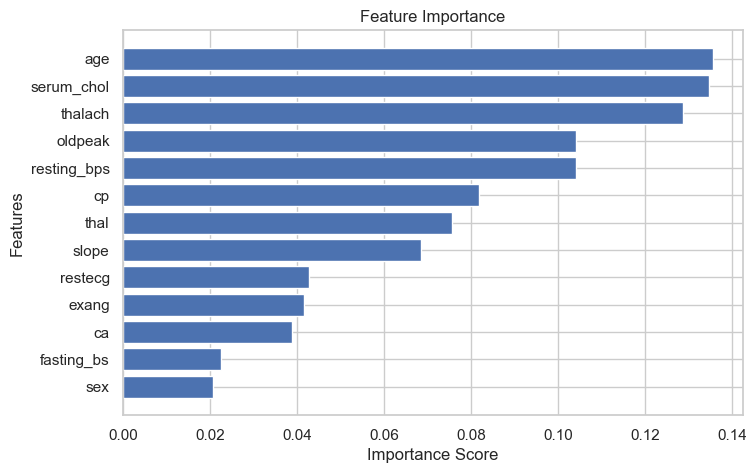

In [43]:
import matplotlib.pyplot as plt

plt.figure()
plt.barh(importance_df["feature"], importance_df["importance"])
plt.gca().invert_yaxis()
plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.title("Feature Importance")
plt.show()

In [44]:
df_plot = df.copy()

df_plot["num"] = df_plot["num"].apply(lambda x: 0 if x == 0 else 1)

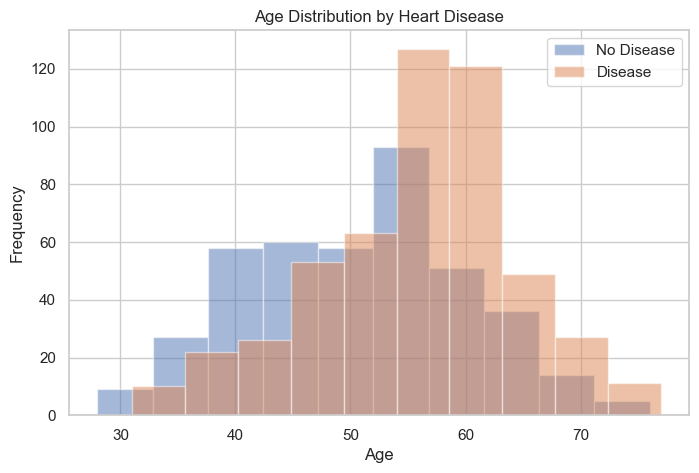

In [45]:
import matplotlib.pyplot as plt

no_disease = df_plot[df_plot["num"] == 0]
disease = df_plot[df_plot["num"] == 1]

plt.figure()

plt.hist(no_disease["age"], alpha=0.5, label="No Disease")
plt.hist(disease["age"], alpha=0.5, label="Disease")

plt.xlabel("Age")
plt.ylabel("Frequency")
plt.title("Age Distribution by Heart Disease")
plt.legend()

plt.show()

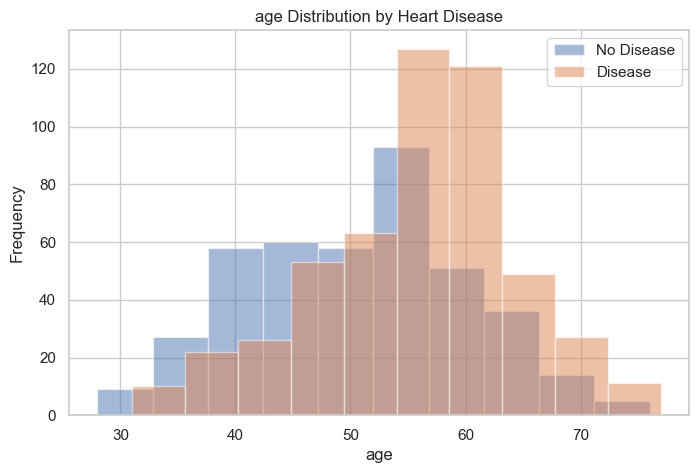

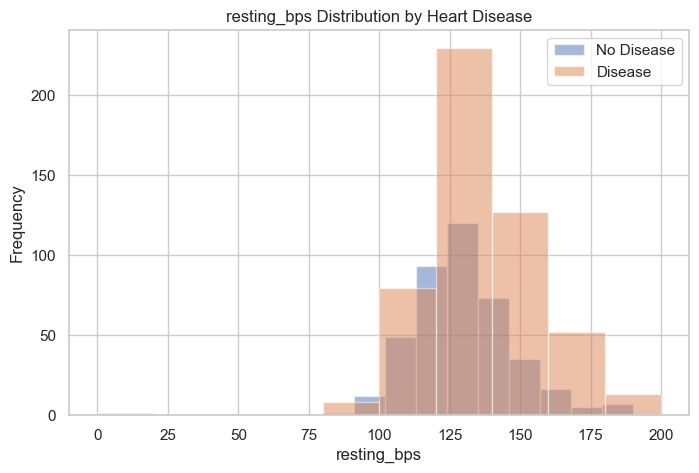

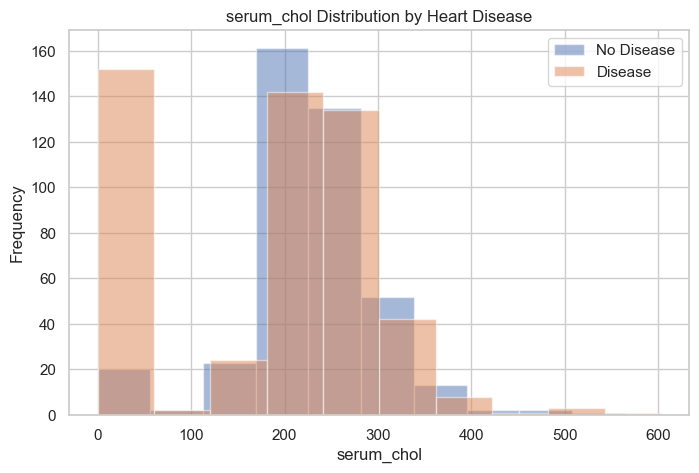

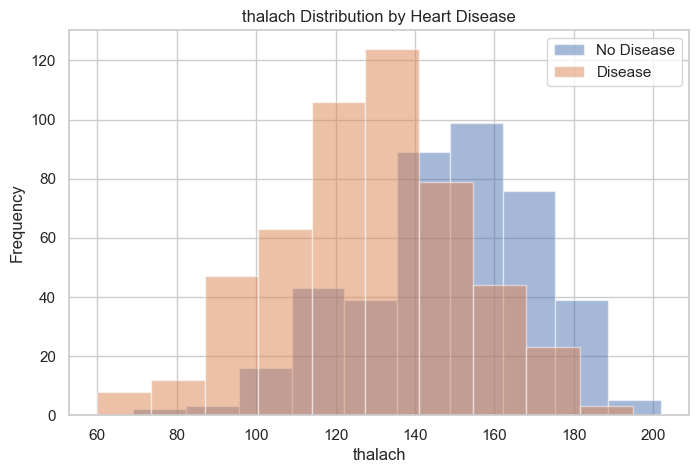

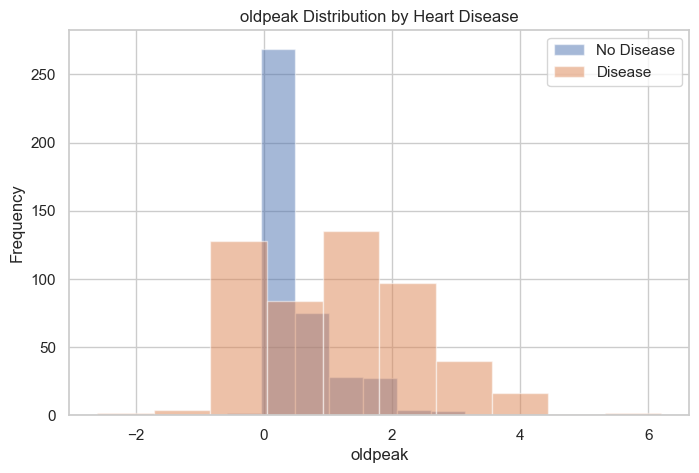

In [46]:
features_to_plot = ["age", "resting_bps", "serum_chol", "thalach", "oldpeak"]
for col in features_to_plot:
    plt.figure()
    plt.hist(no_disease[col], alpha=0.5, label="No Disease")
    plt.hist(disease[col], alpha=0.5, label="Disease")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.title(f"{col} Distribution by Heart Disease")
    plt.legend()
    plt.show()

<Figure size 800x500 with 0 Axes>

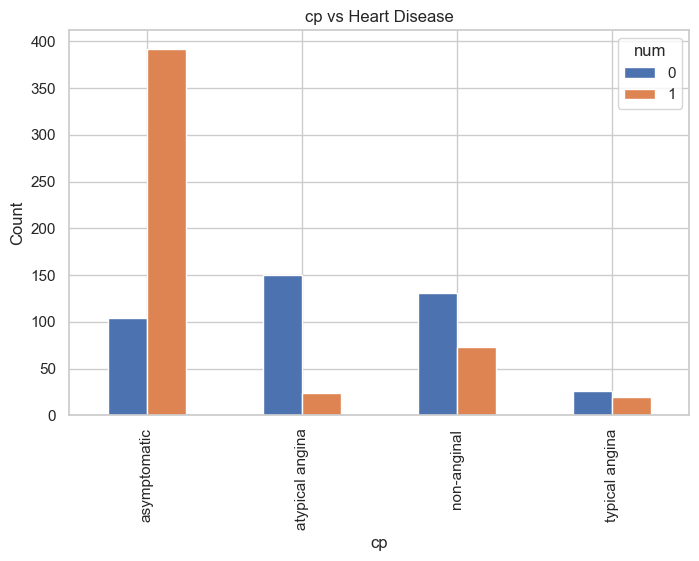

<Figure size 800x500 with 0 Axes>

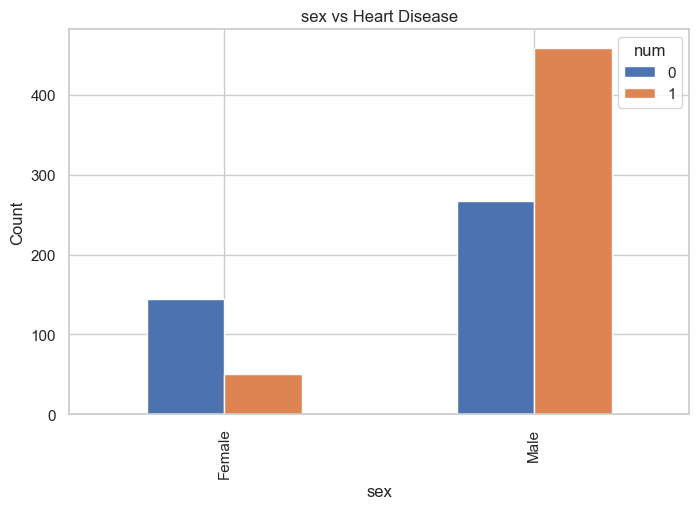

<Figure size 800x500 with 0 Axes>

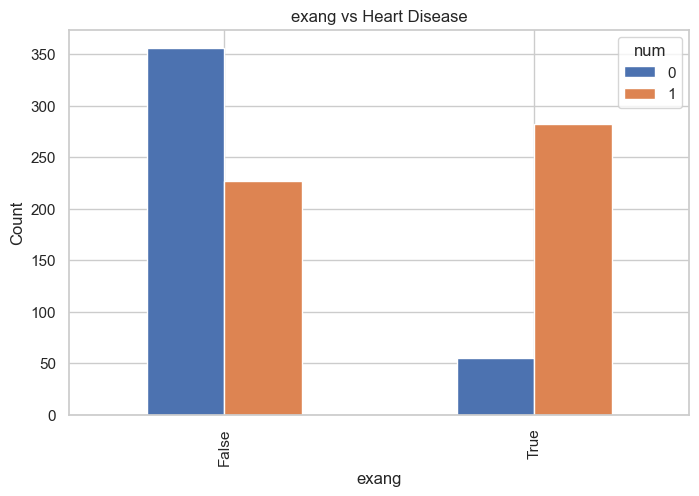

<Figure size 800x500 with 0 Axes>

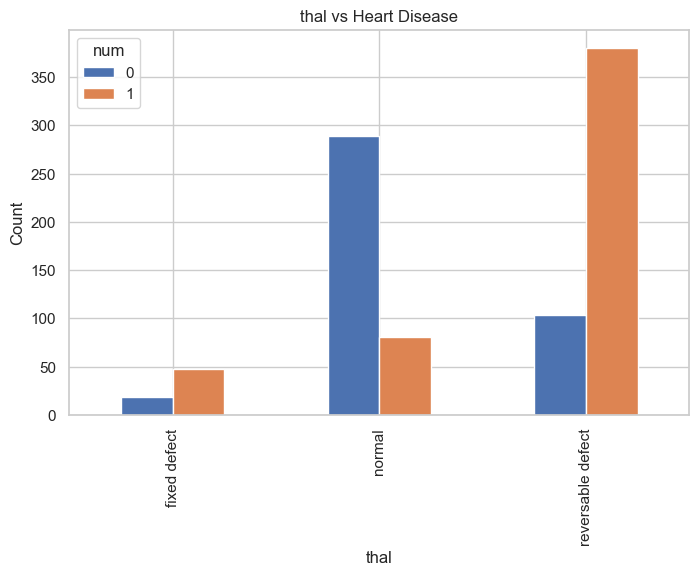

<Figure size 800x500 with 0 Axes>

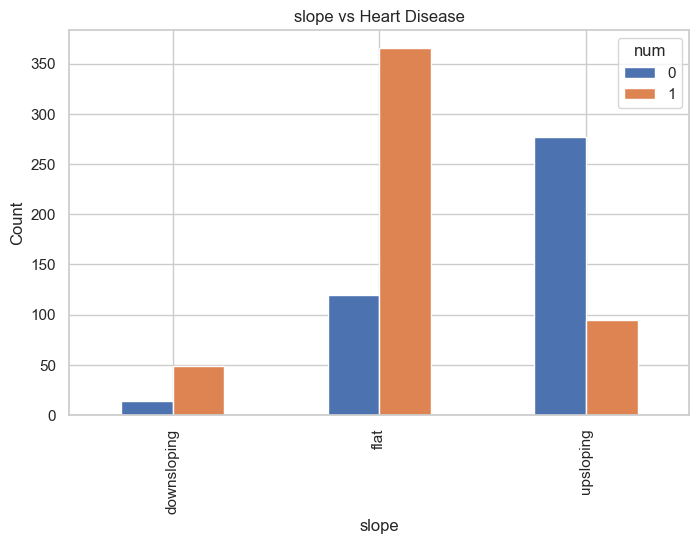

In [47]:
import pandas as pd

cat_features = ["cp", "sex", "exang", "thal", "slope"]

for col in cat_features:
    plt.figure()
    
    pd.crosstab(df_plot[col], df_plot["num"]).plot(kind="bar")
    
    plt.title(f"{col} vs Heart Disease")
    plt.xlabel(col)
    plt.ylabel("Count")
    
    plt.show()

In [48]:
selected_features = [
    "age",
    "serum_chol",
    "thalach",
    "oldpeak",
    "resting_bps",
    "cp",
    "thal",
    "slope",
    "ca",
    "exang"
]

In [49]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# prepare data
df_model = df.copy()
df_model["num"] = df_model["num"].apply(lambda x: 0 if x == 0 else 1)

X = df_model[selected_features]
y = df_model["num"]

# encode if needed
from sklearn.preprocessing import LabelEncoder

for col in X.columns:
    if X[col].dtype == 'object':
        le = LabelEncoder()
        X[col] = le.fit_transform(X[col])

# split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

# train
model = RandomForestClassifier(
    n_estimators=500,
    max_depth=10,
    random_state=42,
    n_jobs=-1)

model.fit(X_train, y_train)
# evaluate
y_pred = model.predict(X_test)

print("Random forest Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

C:\Users\chris\AppData\Local\Temp\ipykernel_17088\3563983314.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X[col] = le.fit_transform(X[col])
C:\Users\chris\AppData\Local\Temp\ipykernel_17088\3563983314.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X[col] = le.fit_transform(X[col])
C:\Users\chris\AppData\Local\Temp\ipykernel_17088\3563983314.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead


Random forest Accuracy: 0.8858695652173914
              precision    recall  f1-score   support

           0       0.85      0.88      0.86        75
           1       0.92      0.89      0.90       109

    accuracy                           0.89       184
   macro avg       0.88      0.88      0.88       184
weighted avg       0.89      0.89      0.89       184



In [50]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [51]:
import xgboost as xgb
model_xgb = xgb.XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss'
)

model_xgb.fit(X_train, y_train)

C:\Users\chris\AppData\Roaming\Python\Python313\site-packages\xgboost\training.py:183: UserWarning: [04:42:00] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=5, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=300, n_jobs=None,
              num_parallel_tree=None, ...)

In [52]:
from sklearn.metrics import accuracy_score, classification_report

y_pred_xgb = model_xgb.predict(X_test)

print("XGBoost Accuracy:", accuracy_score(y_test, y_pred_xgb))
print(classification_report(y_test, y_pred_xgb))

XGBoost Accuracy: 0.8967391304347826
              precision    recall  f1-score   support

           0       0.85      0.91      0.88        75
           1       0.93      0.89      0.91       109

    accuracy                           0.90       184
   macro avg       0.89      0.90      0.89       184
weighted avg       0.90      0.90      0.90       184



In [53]:
# RandomForest (reuse your previous model)
y_pred_rf = model.predict(X_test)

print("RandomForest Accuracy:", accuracy_score(y_test, y_pred_rf))
print("XGBoost Accuracy:", accuracy_score(y_test, y_pred_xgb))

RandomForest Accuracy: 0.8858695652173914
XGBoost Accuracy: 0.8967391304347826


In [54]:
import pandas as pd

xgb_importance = pd.DataFrame({
    "feature": selected_features,
    "importance": model_xgb.feature_importances_
}).sort_values(by="importance", ascending=False)

print(xgb_importance)

       feature  importance
5           cp    0.214840
7        slope    0.196497
6         thal    0.143923
8           ca    0.103725
9        exang    0.096300
1   serum_chol    0.061718
3      oldpeak    0.059920
2      thalach    0.042557
0          age    0.041857
4  resting_bps    0.038663


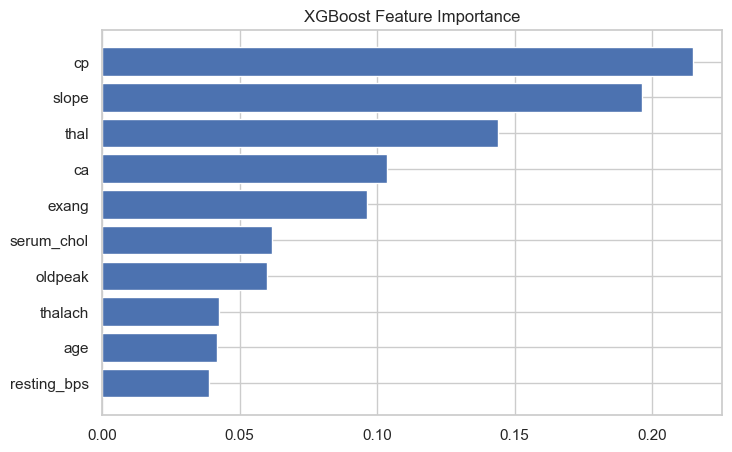

In [55]:
import matplotlib.pyplot as plt

plt.figure()
plt.barh(xgb_importance["feature"], xgb_importance["importance"])
plt.gca().invert_yaxis()
plt.title("XGBoost Feature Importance")
plt.show()

In [56]:
y_prob_xgb = model_xgb.predict_proba(X_test)[:, 1]
y_prob_rf = model.predict_proba(X_test)[:, 1]

from sklearn.metrics import roc_curve

fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_prob_xgb)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)

In [57]:
from sklearn.metrics import roc_auc_score

auc_xgb = roc_auc_score(y_test, y_prob_xgb)
auc_rf = roc_auc_score(y_test, y_prob_rf)

print("XGBoost AUC:", auc_xgb)
print("RandomForest AUC:", auc_rf)

XGBoost AUC: 0.9195107033639144
RandomForest AUC: 0.9160856269113149


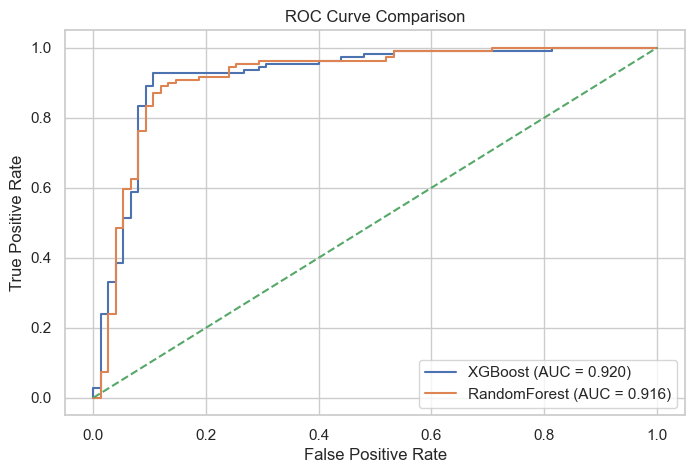

In [58]:
import matplotlib.pyplot as plt

plt.figure()

plt.plot(fpr_xgb, tpr_xgb, label=f"XGBoost (AUC = {auc_xgb:.3f})")
plt.plot(fpr_rf, tpr_rf, label=f"RandomForest (AUC = {auc_rf:.3f})")

# diagonal line (random model)
plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()

plt.show()

In [73]:
import joblib
joblib.dump(model_xgb, "xgboost_heart_model.pkl") # save the model for reusability without need to relearn anytime the kernel runs

['xgboost_heart_model.pkl']

In [74]:
import numpy as np
import joblib

# Load pipeline
pipeline = joblib.load("xgboost_heart_model.pkl")

def predict_heart_disease():
    print("Enter patient details:\n")

    age = float(input("Age: "))
    chol = float(input("Cholesterol: "))
    thalach = float(input("Max Heart Rate: "))
    oldpeak = float(input("Oldpeak: "))
    trestbps = float(input("Resting BP: "))
    cp = int(input("Chest Pain Type (0-3): "))
    thal = int(input("Thal (1-3): "))
    slope = int(input("Slope (0-2): "))
    ca = int(input("Number of vessels (0-3): "))
    exang = int(input("Exercise Angina (0 = No, 1 = Yes): "))

    # Arrange in correct order
    sample = np.array([[age, chol, thalach, oldpeak, trestbps,
                        cp, thal, slope, ca, exang]])

    # Predict
    prediction = pipeline.predict(sample)[0]
    probability = pipeline.predict_proba(sample)[0][1]

    print("\n--- RESULT ---")
    print("Prediction:", "Heart Disease" if prediction == 1 else "No Heart Disease")
    print(f"Confidence: {probability:.2f}")

# Run
predict_heart_disease()

Enter patient details:



Age:  23
Cholesterol:  250
Max Heart Rate:  70
Oldpeak:  50
Resting BP:  120
Chest Pain Type (0-3):  0
Thal (1-3):  1
Slope (0-2):  1
Number of vessels (0-3):  0
Exercise Angina (0 = No, 1 = Yes):  1



--- RESULT ---
Prediction: Heart Disease
Confidence: 0.92


### Implementing the SHAP

In [82]:
import shap                    # SHAP library for explainability
import joblib                  # For loading saved models
# Load the trained XGBoost model from file
model = joblib.load("xgboost_heart_model.pkl")

# Define the exact feature order used during training
feature_names = [
    "age",
    "chol",
    "thalch",
    "oldpeak",
    "trestbps",
    "cp",
    "thal",
    "slope",
    "ca",
    "exang"
]

# Create SHAP TreeExplainer for tree-based models like XGBoost
explainer = shap.TreeExplainer(model)
# Create a sample input (like user input)
sample_data = {
    "age": 58,
    "chol": 260,
    "thalch": 120,
    "oldpeak": 2.5,
    "trestbps": 140,
    "cp": 3,
    "thal": 2,
    "slope": 1,
    "ca": 2,
    "exang": 1
}

# Convert dictionary to DataFrame (required format for SHAP + model)
sample_df = pd.DataFrame([sample_data])
# Calculate SHAP values for the sample input
shap_values = explainer.shap_values(sample_df)

In [83]:
# Initialize JS visualization (required in Jupyter)
shap.initjs()

# Create force plot for first sample
shap.force_plot(
    explainer.expected_value,       # base value (average prediction)
    shap_values[0],                 # SHAP values for this sample
    sample_df                       # original feature values
)

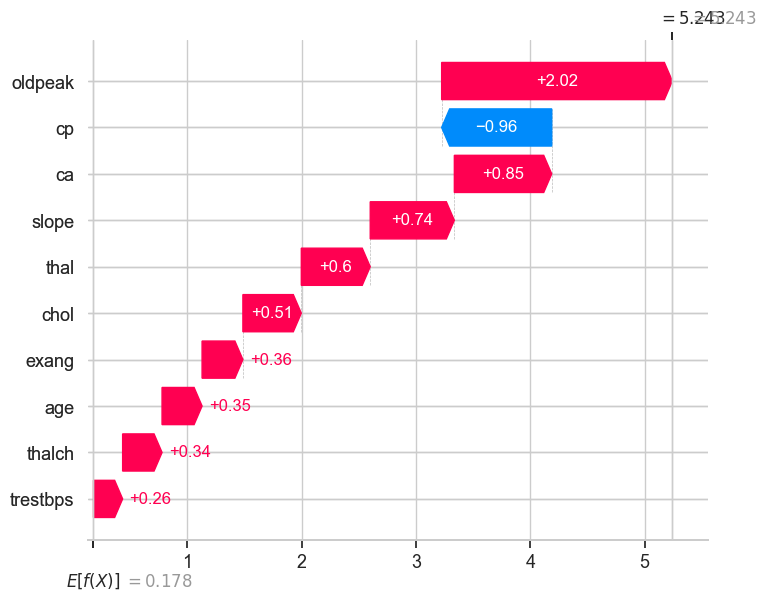

In [84]:
# Waterfall plot shows feature contribution clearly
shap.plots._waterfall.waterfall_legacy(
    explainer.expected_value,
    shap_values[0],
    feature_names=feature_names
)